In [1]:
import numpy as np
import pandas as pd

Load the dataset

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')

In [3]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
print(df.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [5]:
df.shape

(891, 12)

In [6]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


Data Cleaning

In [7]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
df['Age'].fillna(df['Age'].mean(), inplace = True)

/tmp/ipykernel_18735/2940318962.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace = True)


In [9]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
df.dropna(inplace=True)

In [11]:
print(df.groupby('Sex')['Survived'].mean())

Sex
female    0.936842
male      0.420561
Name: Survived, dtype: float64


In [12]:
df_sorted = df.sort_values(by = 'Age', ascending=True)
print(df_sorted.head())

     PassengerId  Survived  Pclass                            Name     Sex  \
305          306         1       1  Allison, Master. Hudson Trevor    male   
183          184         1       2       Becker, Master. Richard F    male   
205          206         0       3      Strom, Miss. Telma Matilda  female   
297          298         0       1    Allison, Miss. Helen Loraine  female   
340          341         1       2  Navratil, Master. Edmond Roger    male   

      Age  SibSp  Parch  Ticket      Fare    Cabin Embarked  
305  0.92      1      2  113781  151.5500  C22 C26        S  
183  1.00      2      1  230136   39.0000       F4        S  
205  2.00      0      1  347054   10.4625       G6        S  
297  2.00      1      2  113781  151.5500  C22 C26        S  
340  2.00      1      1  230080   26.0000       F2        S  


In [13]:
df['Family Size'] = df['SibSp'] + df['Parch']
print(df)

     PassengerId  Survived  Pclass  \
1              2         1       1   
3              4         1       1   
6              7         0       1   
10            11         1       3   
11            12         1       1   
..           ...       ...     ...   
871          872         1       1   
872          873         0       1   
879          880         1       1   
887          888         1       1   
889          890         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                              McCarthy, Mr. Timothy J    male  54.0      0   
10                     Sandstrom, Miss. Marguerite Rut  female   4.0      1   
11                            Bonnell, Miss. Elizabeth  female  58.0      0   
..                                                 ...     ...   ... 

In [14]:
print(df['Fare'].max())

512.3292


In [15]:
df.to_csv('Cleaned Dataset.csv')

Data Visualization

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

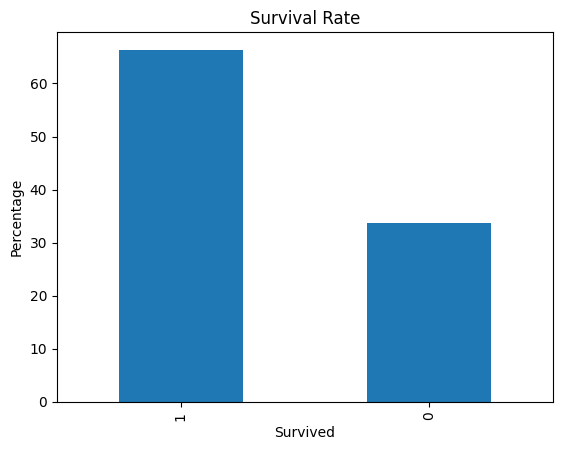

In [17]:
survival_rate = df['Survived'].value_counts(normalize=True)*100
survival_rate.plot(kind='bar')
plt.xlabel('Survived')
plt.ylabel('Percentage')
plt.title('Survival Rate')
plt.show()

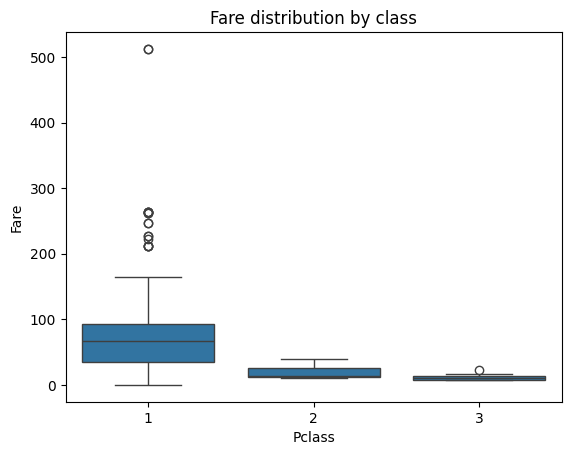

In [18]:
sns.boxplot(x = 'Pclass', y = 'Fare',data = df)
plt.title('Fare distribution by class')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [20]:
df['Embarked'].fillna('S',inplace=True)

/tmp/ipykernel_18735/3895404187.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S',inplace=True)


In [21]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

Categorical data to Numeric data

In [22]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})
print(df)

     Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Family Size
1           1       1    1  38.0      1      0  71.2833         1            1
3           1       1    1  35.0      1      0  53.1000         0            1
6           0       1    0  54.0      0      0  51.8625         0            0
10          1       3    1   4.0      1      1  16.7000         0            2
11          1       1    1  58.0      0      0  26.5500         0            0
..        ...     ...  ...   ...    ...    ...      ...       ...          ...
871         1       1    1  47.0      1      1  52.5542         0            2
872         0       1    0  33.0      0      0   5.0000         0            0
879         1       1    1  56.0      0      1  83.1583         1            1
887         1       1    1  19.0      0      0  30.0000         0            0
889         1       1    0  26.0      0      0  30.0000         1            0

[202 rows x 9 columns]


In [23]:
x = df.drop('Survived', axis= 1)
y = df['Survived']

Splitting into testing and training set

In [24]:
x_train, x_test, y_train, y_test  = train_test_split(
    x,y, test_size = 0.2, random_state = 42
)

Training the model

In [25]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

Testing the model

In [26]:
y_pred = model.predict(x_test)
print(y_pred)

[0 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1]


Accuracy

In [27]:
print("Accuracy", accuracy_score(y_test, y_pred))

Accuracy 0.8292682926829268


Confusion Matrix

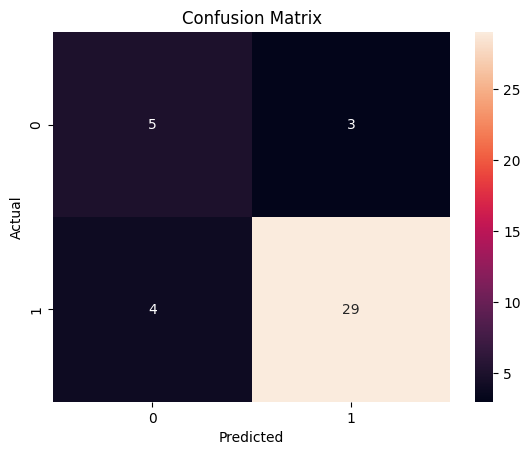

In [28]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()